In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle

import matplotlib.pyplot as plt

from models_transformer import SingleOutTransformerNet
from attention_rollout_helpers import compute_rollout_over_dataloader, get_batch_rollout
from attention_rollout_helpers import get_rollout_importance
from attention_rollout_helpers import extract_attention, process_attention

### Load data

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_data = np.load("data_processed/test_data_scaled.npz")
X_test = test_data["x"]    
y_test = test_data["age"]    
test_loader = DataLoader(X_test, batch_size=32, shuffle=False)

### Load model

In [3]:
IN_DIM = X_test.shape[1]

EMB_DIM = 64
NHEAD = 4
NUM_LAYERS = 11
FF_DIM = 128
DROPOUT = 0.1

model = SingleOutTransformerNet(IN_DIM, emb_dim=EMB_DIM, nhead=NHEAD, 
                                num_layers=NUM_LAYERS, ff_dim=FF_DIM, 
                                dropout=DROPOUT).to(DEVICE)

state_dict = torch.load(f"trained_models/{NUM_LAYERS}layers/TR_model_{NUM_LAYERS}layers.pt")
model.load_state_dict(state_dict)

<All keys matched successfully>

### Extract attention and value matrices

In [4]:
attn_matrices, values_matrices = extract_attention(model, test_loader, device=DEVICE)
attn_matrices_dict = process_attention(attn_matrices)

# with open(f"Results/rollout_local/{NUM_LAYERS}layers/attn_matrices{NUM_LAYERS}layers.pkl", 
#           "wb") as f:
#     pickle.dump(attn_matrices_dict, f)

# with open(f"Results/rollout_local/{NUM_LAYERS}layers/value_matrices{NUM_LAYERS}layers.pkl", 
#           "wb") as f:
#     pickle.dump(values_matrices, f)

### Compute rollout

In [5]:
results = compute_rollout_over_dataloader(model=model, 
                                          dataloader=test_loader, 
                                          device=DEVICE, 
                                          add_residual=True, 
                                          residual_weight=1.0, 
                                          head_fusion="mean", 
                                          normalize=True)

rollout_mean = results['rollout_mean'].numpy()
feature_importance_mean = rollout_mean.sum(axis=0)

rollout = results['rollout'].cpu().numpy()
feature_importance = rollout.sum(axis=1)

# np.savez_compressed(
#     f"Results/rollout_local/{NUM_LAYERS}layers/rollout{NUM_LAYERS}layers.npz", 
#     rollout=rollout,
#     importance=feature_importance)

# np.savez_compressed(
#     f"Results/rollout_global/{NUM_LAYERS}layers/rollout{NUM_LAYERS}layers.npz",
#     rollout=rollout_mean,
#     importance=feature_importance_mean)

In [6]:
import torch

@torch.no_grad()
def rollout_sensitivity_by_feature(
    model,
    X,
    compute_rollout,
    eps=1e-2,
    max_samples=256,
    device="cuda"
):
    """
    model: trained transformer
    X: tensor of shape (N, d), already normalized as during training
    compute_rollout(model, x_batch): returns rollout matrices of shape (B, d, d)
    eps: perturbation size in normalized feature units
    """

    model.eval()
    X = X[:max_samples].to(device)
    B, d = X.shape

    R0 = compute_rollout(model, X)  # (B, d, d)
    R0_np = R0['rollout']
    
    sensitivities = []

    for j in range(d):
        Xp = X.clone()
        Xp[:, j] += eps

        Rp = compute_rollout(model, Xp)
        Rp_np = Rp['rollout']
        
        diff = Rp_np - R0_np

        num = torch.linalg.norm(diff.reshape(B, -1), dim=1)
        den = eps * torch.linalg.norm(R0_np.reshape(B, -1), dim=1).clamp_min(1e-12)

        Sj = num / den
        sensitivities.append(Sj.cpu())

    sensitivities = torch.stack(sensitivities, dim=1)  # (B, d)

    return {
        "mean": sensitivities.mean(dim=0),
        "median": sensitivities.median(dim=0).values,
        "max": sensitivities.max(dim=0).values,
        "all": sensitivities,
    }

In [7]:
result_eps = rollout_sensitivity_by_feature(
    model=model,
    X=torch.Tensor(X_test),
    compute_rollout=get_batch_rollout,
    eps=1e-2,
    max_samples=256,
    device=DEVICE,
)

mean_sensitivity = result_eps["mean"]

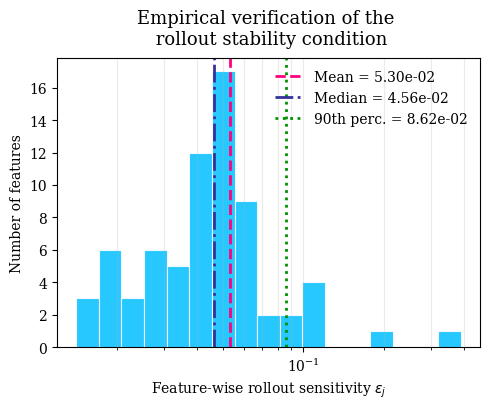

In [8]:
plt.rcParams.update({"font.family": "serif"})

eps = np.asarray(mean_sensitivity, dtype=float)

# Remove invalid values, if any
eps = eps[np.isfinite(eps)]
eps = eps[eps > 0]

mean_eps = eps.mean()
median_eps = np.median(eps)

# Optional: define tail as top 10%
q90 = np.quantile(eps, 0.90)

fig, ax = plt.subplots(figsize=(5, 4.2))

# Log-spaced bins
bins = np.logspace(np.log10(eps.min()), np.log10(eps.max()), 18)

ax.hist(
    eps,
    bins=bins,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85,
    color="#00BFFF",
)

ax.axvline(mean_eps, color="#FF007F", linestyle="--", 
           linewidth=2, label=fr"Mean = {mean_eps:.2e}")
ax.axvline(median_eps+7e-4, color="#333399", linestyle="-.", 
           linewidth=2, label=fr"Median = {median_eps:.2e}")
ax.axvline(q90, linestyle=":", color="#009000", 
           linewidth=2, label=fr"90th perc. = {q90:.2e}")

ax.set_xscale("log")
ax.set_xlabel(r"Feature-wise rollout sensitivity $\varepsilon_j$")
ax.set_ylabel("Number of features")
ax.set_title("Empirical verification of the \n rollout stability condition", fontsize=13, pad=10)

ax.legend(frameon=False)
ax.grid(True, which="both", axis="x", alpha=0.25)

fig.tight_layout()
# fig.savefig("Results/sensitivity_histogram.pdf", bbox_inches="tight")

plt.show()

In [9]:
def compute_cj(R_list):
    """
    R_list: list of (d,d) rollout matrices
    returns: array (N,d) with c_j(X_n)
    """
    N = len(R_list)
    d = R_list[0].shape[0]

    c = np.zeros((N, d))
    
    for n, R in enumerate(R_list):
        c[n] = np.sum(R, axis=0)  # column sums
    
    return c

In [10]:
def compute_delta_j(X, c):
    """
    X: (N,d)
    c: (N,d) column sums
    
    returns:
        delta_j: (d,)
    """
    N, d = X.shape
    
    absX = np.abs(X)

    delta = np.zeros(d)
    
    for j in range(d):
        term1 = np.mean(c[:, j] * absX[:, j])
        term2 = np.mean(c[:, j]) * np.mean(absX[:, j])
        
        delta[j] = np.abs(term1 - term2)
    
    return delta

In [11]:
def normalize_delta(delta, c, X):
    Cj = np.mean(np.abs(X), axis=0)
    sj = np.mean(c, axis=0)
    
    return delta / (Cj * sj + 1e-8)

In [12]:
c = compute_cj(results['rollout'].numpy())
deltas = compute_delta_j(X_test, c)
deltas_norm = normalize_delta(deltas, c, X_test)

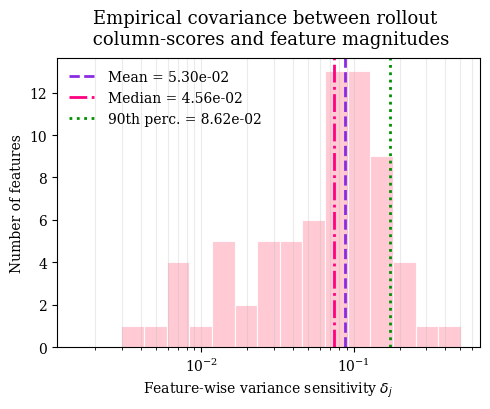

In [13]:
plt.rcParams.update({"font.family": "serif"})

ds = np.asarray(deltas_norm, dtype=float)

# Remove invalid values, if any
ds = ds[np.isfinite(ds)]
ds = ds[ds > 0]

mean_ds = ds.mean()
median_ds = np.median(ds)

# Optional: define tail as top 10%
q90d = np.quantile(ds, 0.90)

fig, ax = plt.subplots(figsize=(5, 4.2))

# Log-spaced bins
bins = np.logspace(np.log10(ds.min()), np.log10(ds.max()), 18)

ax.hist(
    ds,
    bins=bins,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85,
    color="#FFC1CC",
)

ax.axvline(mean_ds, color="#8A2BE2", linestyle="--", 
           linewidth=2, label=fr"Mean = {mean_eps:.2e}")
ax.axvline(median_ds+7e-4, color="#FF007F", linestyle="-.", 
           linewidth=2, label=fr"Median = {median_eps:.2e}")
ax.axvline(q90d, linestyle=":", color="#009000", 
           linewidth=2, label=fr"90th perc. = {q90:.2e}")

ax.set_xscale("log")
ax.set_xlabel(r"Feature-wise variance sensitivity $\delta_j$")
ax.set_ylabel("Number of features")
ax.set_title("Empirical covariance between rollout \n column-scores and feature magnitudes", 
             fontsize=13, pad=10)

ax.legend(frameon=False, fontsize=10)
ax.grid(True, which="both", axis="x", alpha=0.25)

fig.tight_layout()
# fig.savefig("Results/variance_histogram.pdf", bbox_inches="tight")

plt.show()